<a href="https://colab.research.google.com/github/Suryansh-Kushwaha2025/CASE_STUDY_1/blob/main/CaseStudy1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#HOSPITAL READMISSION PREDICTION
#Logistic Regression with L2 Regularization



In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score
)

#Read CSV

In [11]:
df = pd.read_csv("diabetic_data.csv")

print("Shape:", df.shape)
df.head()
print(df.columns.tolist())

Shape: (101766, 50)
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [12]:
df["readmitted_30"] = (df["readmitted"] == "<30").astype(int)

print(df["readmitted_30"].value_counts())

readmitted_30
0    90409
1    11357
Name: count, dtype: int64


# Remove unnecessary columns

In [13]:
drop_cols = [
    "encounter_id",
    "patient_nbr",
    "readmitted"
]

df = df.drop(columns=drop_cols)

print(df.shape)

(101766, 48)


# Handle missing values

In [14]:
df = df.replace("?", np.nan)
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64


# Select useful features

In [15]:
features = [
    "race",
    "gender",
    "age",
    "diag_1",
    "diag_2",
    "diag_3",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications"
]

X = df[features]
y = df["readmitted_30"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (101766, 13)
y shape: (101766,)


# Separate numerical and categorical features

In [16]:
categorical_features = [
    "race",
    "gender",
    "age",
    "diag_1",
    "diag_2",
    "diag_3"
]

numerical_features = [
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications"
]

# Preprocessing

In [17]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Train-test split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (81412, 13)
Testing: (20354, 13)


# Logistic Regression with L2 Regularization

In [19]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        penalty="l2",
        C=1.0,
        max_iter=1000,
        solver="liblinear"
    ))
])

In [20]:
# Train the model

In [21]:
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


#Make predictions

In [22]:
y_prob = model.predict_proba(X_test)[:, 1]

#ROC-AUC

In [23]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.6404266612198903


# Plot ROC curve

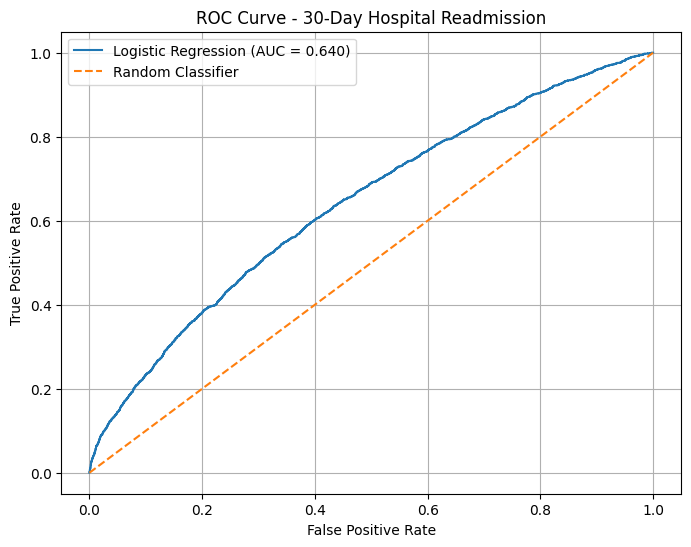

In [24]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 30-Day Hospital Readmission")
plt.legend()
plt.grid()

plt.show()

# Classification using 0.5 threshold

In [25]:
threshold = 0.5

y_pred = (y_prob >= threshold).astype(int)

# Confusion Matrix


[[18037    46]
 [ 2224    47]]


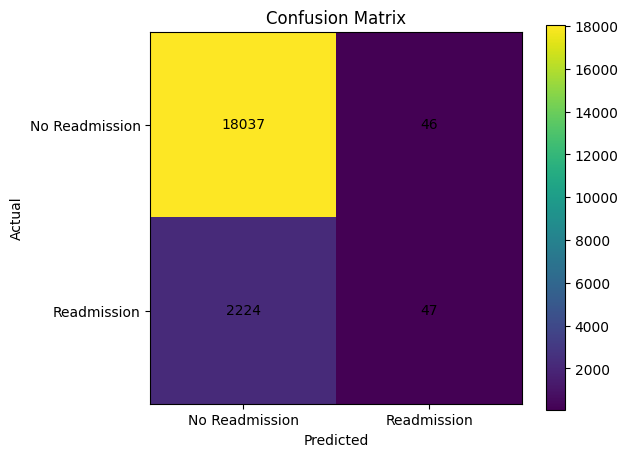

In [26]:

cm = confusion_matrix(y_test, y_pred)

print(cm)
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["No Readmission", "Readmission"])
plt.yticks([0, 1], ["No Readmission", "Readmission"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.colorbar()
plt.show()

#Classification Report

In [27]:
print(classification_report(
    y_test,
    y_pred,
    target_names=[
        "No 30-day Readmission",
        "30-day Readmission"
    ]
))
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("ROC-AUC  :", roc_auc)

                       precision    recall  f1-score   support

No 30-day Readmission       0.89      1.00      0.94     18083
   30-day Readmission       0.51      0.02      0.04      2271

             accuracy                           0.89     20354
            macro avg       0.70      0.51      0.49     20354
         weighted avg       0.85      0.89      0.84     20354

Accuracy : 0.8884740100226
Precision: 0.5053763440860215
Recall   : 0.020695728753852928
ROC-AUC  : 0.6404266612198903


# 8. ROC-AUC

In [29]:
auc = roc_auc_score(y_test, y_prob)

print()
print("=============================")
print("MODEL PERFORMANCE")
print("=============================")

print("ROC-AUC:", round(auc, 4))


MODEL PERFORMANCE
ROC-AUC: 0.6404


# 9. CONFUSION MATRIX

In [30]:
cm = confusion_matrix(y_test, y_pred)

print()
print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[18037    46]
 [ 2224    47]]


# 10. CLASSIFICATION REPORT

In [31]:
print()
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.51      0.02      0.04      2271

    accuracy                           0.89     20354
   macro avg       0.70      0.51      0.49     20354
weighted avg       0.85      0.89      0.84     20354



# 11. EXTRACT TP, FP, FN, TN

In [33]:
tn, fp, fn, tp = cm.ravel()

print()
print("==============================")
print("CLINICAL ERROR ANALYSIS")
print("==============================")

print("True Negatives  :", tn)
print("False Positives :", fp)
print("False Negatives :", fn)
print("True Positives  :", tp)


CLINICAL ERROR ANALYSIS
True Negatives  : 18037
False Positives : 46
False Negatives : 2224
True Positives  : 47


# 12. ROC CURVE

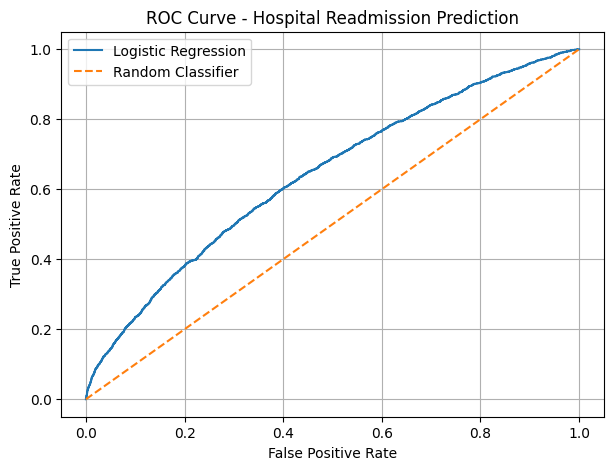

In [35]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label="Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Hospital Readmission Prediction")

plt.legend()

plt.grid()

plt.show()

# 13. PREDICT A NEW PATIENT

In [37]:
# 13. PREDICT A NEW PATIENT

# Create new patient data matching the features used for training
# Using example values for numerical features and appropriate categories for categorical features.
new_patient = pd.DataFrame([{
    "race": "Caucasian",
    "gender": "Male",
    "age": "[70-80)",
    "diag_1": "401", # Example diagnosis code
    "diag_2": "250", # Example diagnosis code
    "diag_3": "428", # Example diagnosis code
    "number_outpatient": 0,
    "number_emergency": 0,
    "number_inpatient": 0,
    "time_in_hospital": 5,
    "num_lab_procedures": 30,
    "num_procedures": 1,
    "num_medications": 15
}])

# Preprocess the new patient using the preprocessor from the trained model pipeline
new_patient_processed = model.named_steps['preprocessor'].transform(new_patient)

# Predict probability of readmission
new_probability = model.named_steps['classifier'].predict_proba(new_patient_processed)[:, 1]

print("=============================")
print("     NEW PATIENT PREDICTION")
print("=============================")

print(
    "Readmission probability:",
    round(new_probability[0] * 100, 2),
    "%"
)

# Classification using 0.5 threshold
if new_probability[0] >= 0.5:
    print("Prediction: HIGH RISK of readmission")
else:
    print("Prediction: LOW RISK of readmission")

     NEW PATIENT PREDICTION
Readmission probability: 8.35 %
Prediction: LOW RISK of readmission
